In [1]:
import os
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
dde.backend.backend_name = "pytorch"
import matplotlib.pyplot as plt
import numpy as np

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
geom = dde.geometry.Interval(-5, 5)
timedomain = dde.geometry.TimeDomain(0, np.pi / 2)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

In [16]:
def pde(x, y):

    u = y[:, 0:1]
    v = y[:, 1:2]

    du_dt = dde.grad.jacobian(y, x, i=0, j=1)
    du_xx = dde.grad.hessian(y, x, component=0, i=0, j=0)

    dv_dt = dde.grad.jacobian(y, x, i=1, j=1)
    dv_xx = dde.grad.hessian(y, x, component=1, i=0, j=0)

    f_u = du_dt + 0.5*du_xx + u*(u**2 + v**2)
    f_v = -dv_dt + 0.5*dv_xx + v*(u**2 + v**2)

    return [f_u, f_v]

In [7]:
def is_on_boundary(x, on_boundary):
    return on_boundary

def is_initial(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[1], 0)

def ic_u_value(x):
    return 2 / np.cosh(x[:, 0:1])

def ic_v_value(x):
    return np.zeros_like(x[:, 1:2])

In [9]:
bc_u = dde.icbc.PeriodicBC(geomtime, 0, is_on_boundary, derivative_order=0, component=0)
bc_v = dde.icbc.PeriodicBC(geomtime, 0, is_on_boundary, derivative_order=0, component=1)

bc_u_x = dde.icbc.PeriodicBC(geomtime, 0, is_on_boundary, derivative_order=1, component=0)
bc_v_x = dde.icbc.PeriodicBC(geomtime, 0, is_on_boundary, derivative_order=1, component=0)

In [12]:
ic_u = dde.icbc.IC(geomtime, ic_u_value, is_initial, component=0)
ic_v = dde.icbc.IC(geomtime, ic_v_value, is_initial, component=1)

In [17]:
data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc_u, bc_u_x, bc_v, bc_v_x, ic_u, ic_v],
    num_domain=5000,
    num_boundary=200,
    num_initial=200
)

In [18]:
layer_size = [2] + [100]*4 + [2]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)
model = dde.Model(data, net)

model.compile("adam", lr=0.001)

Compiling model...
'compile' took 0.000358 s



In [19]:
model.train(iterations=5000)

Training model...

Step      Train loss                                                                          Test loss                                                                           Test metric
0         [2.23e-03, 7.05e-02, 6.01e-02, 2.83e-05, 2.40e+00, 2.83e-05, 8.05e-01, 2.95e-01]    [2.23e-03, 7.05e-02, 6.01e-02, 2.83e-05, 2.40e+00, 2.83e-05, 8.05e-01, 2.95e-01]    []  
1000      [1.25e-03, 4.28e-05, 3.54e-06, 8.83e-05, 1.27e-06, 8.83e-05, 1.02e-04, 4.60e-06]    [1.25e-03, 4.28e-05, 3.54e-06, 8.83e-05, 1.27e-06, 8.83e-05, 1.02e-04, 4.60e-06]    []  
2000      [6.52e-04, 2.05e-05, 9.68e-07, 3.66e-05, 3.90e-07, 3.66e-05, 9.12e-05, 2.80e-06]    [6.52e-04, 2.05e-05, 9.68e-07, 3.66e-05, 3.90e-07, 3.66e-05, 9.12e-05, 2.80e-06]    []  
3000      [4.77e-04, 1.06e-05, 3.47e-06, 1.55e-05, 1.58e-06, 1.55e-05, 1.11e-04, 2.17e-06]    [4.77e-04, 1.06e-05, 3.47e-06, 1.55e-05, 1.58e-06, 1.55e-05, 1.11e-04, 2.17e-06]    []  
4000      [5.07e-03, 1.25e-05, 2.03e-05, 3.90e-05, 5.49e-05

(<deepxde.model.LossHistory at 0x7e2e1c47c910>,
 <deepxde.model.TrainState at 0x7e2e00c0ba90>)

In [21]:
#Model refinement using L-BFGS optimizer
dde.optimizers.config.set_LBFGS_options(maxiter=10000)
model.compile("L-BFGS")
model.train()

Compiling model...
'compile' took 0.001707 s

Training model...

Step      Train loss                                                                          Test loss                                                                           Test metric
5000      [3.15e-04, 4.73e-06, 7.87e-07, 5.09e-06, 5.36e-07, 5.09e-06, 1.26e-04, 1.05e-06]    [3.15e-04, 4.73e-06, 7.87e-07, 5.09e-06, 5.36e-07, 5.09e-06, 1.26e-04, 1.05e-06]    []  
6000      [1.31e-04, 3.94e-06, 3.24e-07, 4.33e-07, 5.57e-08, 4.33e-07, 1.10e-04, 2.51e-07]    [1.31e-04, 3.94e-06, 3.24e-07, 4.33e-07, 5.57e-08, 4.33e-07, 1.10e-04, 2.51e-07]    []  
7000      [4.95e-05, 3.76e-06, 9.19e-07, 1.43e-07, 3.01e-08, 1.43e-07, 5.08e-05, 4.33e-07]    [4.95e-05, 3.76e-06, 9.19e-07, 1.43e-07, 3.01e-08, 1.43e-07, 5.08e-05, 4.33e-07]    []  
8000      [2.69e-05, 6.54e-07, 3.24e-08, 5.40e-08, 1.03e-08, 5.40e-08, 4.70e-05, 8.58e-08]    [2.69e-05, 6.54e-07, 3.24e-08, 5.40e-08, 1.03e-08, 5.40e-08, 4.70e-05, 8.58e-08]    []  
9000      [2.

(<deepxde.model.LossHistory at 0x7e2e1c47c910>,
 <deepxde.model.TrainState at 0x7e2e00c0ba90>)

In [22]:
#Spatial and temporal grids for plotting
x = np.linspace(-5, 5, 200)
t = np.linspace(0, np.pi / 2, 100)
X, T = np.meshgrid(x, t)
X_test = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

In [23]:
prediction = model.predict(X_test)
u_pred = prediction[:, 0].reshape(100, 200)
v_pred = prediction[:, 1].reshape(100, 200)
h_pred = np.sqrt(u_pred**2 + v_pred**2)

PINNS SOLUTION VERIFICATION

In [26]:
y_symbolic = model.predict(X_test, operator=pde) #operator= pde gives the residuals as the output
f_u = y_symbolic[0].reshape(100, 200)
f_v = y_symbolic[1].reshape(100, 200)

#Residual Stats
f_u_mean = np.mean(np.abs(f_u))
f_v_mean = np.mean(np.abs(f_v))

f_u_max = np.max(np.abs(f_u))
f_v_max = np.max(np.abs(f_v))
#checking the average and max residuals

print(f"Residual of u: Mean-{f_u_mean}, Max-{f_u_max}")
print(f"Residual of v: Mean-{f_v_mean}, Max-{f_v_max}")

Residual of u: Mean-0.003183099441230297, Max-0.027608871459960938
Residual of v: Mean-0.0005646292120218277, Max-0.004449132364243269


In [29]:
#Checking Boundary and Initial Conditions.
u_xm5 = u_pred[:, 0] # u at x = -5 for all t
u_xp5 = u_pred[:, -1] # u ar x = 5 for all t
v_xm5 = v_pred[:, 0]
v_xp5 = v_pred[:, -1]

bc_error_u = np.mean(np.abs(u_xm5 - u_xp5))
bc_error_v = np.mean(np.abs(v_xm5 - v_xp5))

print(f"BC error of u: {bc_error_u:.4e}")
print(f"BC error of v: {bc_error_v:.4e}")

BC error of u: 8.1386e-05
BC error of v: 7.2832e-05


In [30]:
#Initial condition Verification
X_flat = X.flatten()
T_flat = T.flatten()

t0_indices = np.isclose(T_flat, 0)
u_t0 = u_pred[0, :]
v_t0 = v_pred[0, :]
u_true_t0 = 2 / np.cosh(X_flat[t0_indices])

init_error_u = np.mean(np.abs(u_t0 - u_true_t0))
init_error_v = np.mean(np.abs(v_t0))

print(f"Initial Condition of u: {init_error_u:.4e}")
print(f"Initial Condition of v: {init_error_v:.4e}")

Initial Condition of u: 5.8543e-03
Initial Condition of v: 1.6217e-04


Second Level of Analysis:- Energy conservation analysis

In [31]:
    dx = (10) / (len(x)-1)

In [38]:
E_t = np.sum(u_pred**2 + v_pred**2, axis=1)*dx

E_initial = E_t[0]
E_change = np.abs(E_t - E_initial)
max_E_change = np.max(E_change)

print(f"Max energy change: {max_E_change:.4e}")

Max energy change: 6.5331e+00


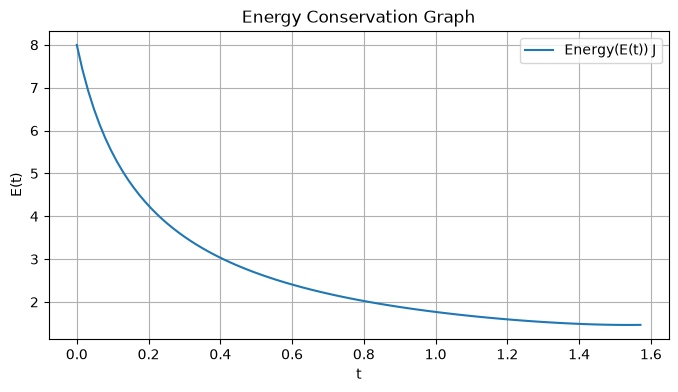

In [39]:
plt.figure(figsize=(8, 4))
plt.plot(t, E_t, label="Energy(E(t)) J")
plt.xlabel("t")
plt.ylabel("E(t)")
plt.title("Energy Conservation Graph")
plt.legend()
plt.grid()
plt.show()
